In [1]:
# Cell 1: Notebook Setup
# ----------------------

# Install requirements if necessary (optional)
# !pip install scanpy openai anndata

# Set display options
import scanpy as sc
import warnings
warnings.filterwarnings("ignore")

# Set matplotlib style
sc.settings.verbosity = 2
sc.set_figure_params(figsize=(5, 5), dpi=100)


In [4]:
# Cell 2: Load Dataset
# --------------------

# You can either load your own dataset:
# adata = sc.read_h5ad("your_dataset.h5ad")

# Or use a built-in sample loader from tic
from tic.data import load_xenium_dataset

adata = load_xenium_dataset(
    name='xenium_ffpe_human_breast'
)
adata


Xenium dataset 'xenium_ffpe_human_breast' already exists at /Users/zhangjiahao/.cache/tic/xenium_ffpe_human_breast
2025-06-05 11:21:58,993 | INFO     | tic.data.xenium.download | Xenium dataset 'xenium_ffpe_human_breast' already exists at /Users/zhangjiahao/.cache/tic/xenium_ffpe_human_breast


reading /Users/zhangjiahao/.cache/tic/xenium_ffpe_human_breast/cell_feature_matrix.h5
 (0:00:00)


2025-06-05 11:22:00,031 INFO Loaded xenium_ffpe_human_breast: 356746 cells * 541 genes.
2025-06-05 11:22:00,031 | INFO     | tic.data.xenium.loader | Loaded xenium_ffpe_human_breast: 356746 cells * 541 genes.


AnnData object with n_obs × n_vars = 356746 × 541
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'tissue_id', 'data_level'
    obsm: 'spatial'

In [5]:
DATASET_DESCRIPTION = """
Demonstration of gene expression profiling for formalin-fixed paraffin-embedded (FFPE) human breast samples on the Xenium platform.
The data were generated with the pre-designed Xenium Human Breast Gene Expression Panel (v1) (base panel). The same experiment was also run with a custom add-on panel of 100 genes.
5µm sections from two resected tumor mass tissues:
Infiltrating ductal carcinoma, Ductal carcinoma in situ (from BiolVT)
Invasive lobular carcinoma (from Avaden Biosciences)
The tissues were prepared following the demonstrated protocols Xenium In Situ for FFPE - Tissue Preparation Guide (CG000578) and Xenium In Situ for FFPE Tissues – Deparaffinization & Decrosslinking (CG000580).
Post-instrument processing followed the demonstrated protocol Xenium In Situ Gene Expression - Post-Xenium Analyzer H&E Staining (CG000613). The registered H&E image file is suitable for annotating regions. It may or may not be suitable for more refined exact sub-cellular resolution correspondence due to minute differences in the optics of the microscopy systems. Learn more in the H&E to Xenium DAPI Image Registration with Fiji Analysis Guide.
"""

In [6]:
# Cell 3: Run Full Annotation Pipeline
# ------------------------------------

from tic.annotation import annotate_adata
from utils.config import API_KEY  # You should place your OpenAI API key here

# Run clustering + marker gene extraction + LLM annotation
adata_pred, cluster_annotation = annotate_adata(
    adata=adata,
    assign_params={
        "min_cells": 0,
        "min_genes": 0,
        "n_pca": 50,
        "n_neighbors": 15,
        "resolution": 2.0,
        "n_filter_highly_variable_genes": 2000,
    },
    llm_model_name="openai",
    llm_kwargs={"api_key": API_KEY, "mirror": True},
    dataset_description=(
        DATASET_DESCRIPTION+
        "This dataset contains tumor cells. Please ensure at least one cluster is annotated as tumor."
    ),
    groupby="leiden",
    rank_genes_groups_method="t-test",
    n_genes=10,
    copy=True,
    return_cluster_annotation=True,
)

# Show cluster-to-cell-type mapping
import json
print(json.dumps(cluster_annotation, indent=2))


normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
`n_top_genes` > `adata.n_var`, returning all genes.
    finished (0:00:00)
computing PCA
    with n_comps=50
    finished (0:00:07)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished (0:00:44)
running Leiden clustering
    finished (0:39:50)
computing UMAP
    finished (0:02:43)
ranking genes


... storing 'feature_types' as categorical
... storing 'genome' as categorical


    finished (0:00:09)


2025-06-05 12:06:16,725 INFO Saved cell-type cache to /Users/zhangjiahao/.cache/tic/xenium_ffpe_human_breast/xenium_ffpe_human_breast_llm_cell_types.parquet
2025-06-05 12:06:16,725 | INFO     | tic.annotation.api | Saved cell-type cache to /Users/zhangjiahao/.cache/tic/xenium_ffpe_human_breast/xenium_ffpe_human_breast_llm_cell_types.parquet


{
  "0": {
    "assigned_cell_type": "Luminal Epithelial / Tumor Cell",
    "reasoning": "Cluster 0 expresses KRT7, TPD52, GATA3, ANKRD30A, TACSTD2, FOXA1, and CCND1, all characteristic of luminal epithelial/breast tumor cells. GATA3, FOXA1, and CCND1 are canonical luminal breast cancer markers. ANKRD30A and TACSTD2 are associated with luminal differentiation, supporting a tumor/epithelial identity."
  },
  "1": {
    "assigned_cell_type": "Luminal Epithelial / Tumor Cell",
    "reasoning": "Marker genes such as GATA3, KRT7, TPD52, TACSTD2, FOXA1, ERBB2, and ESR1 are highly specific for luminal epithelium and luminal-type breast carcinoma cells. FASN and SCD are often upregulated in breast cancer, supporting a tumor/epithelial assignment."
  },
  "2": {
    "assigned_cell_type": "Mast Cell",
    "reasoning": "TPSAB1 (tryptase alpha/beta 1) is a classical mast cell marker. The remaining genes are blanks or controls, consistent with low total expression except for TPSAB1, typical of rare

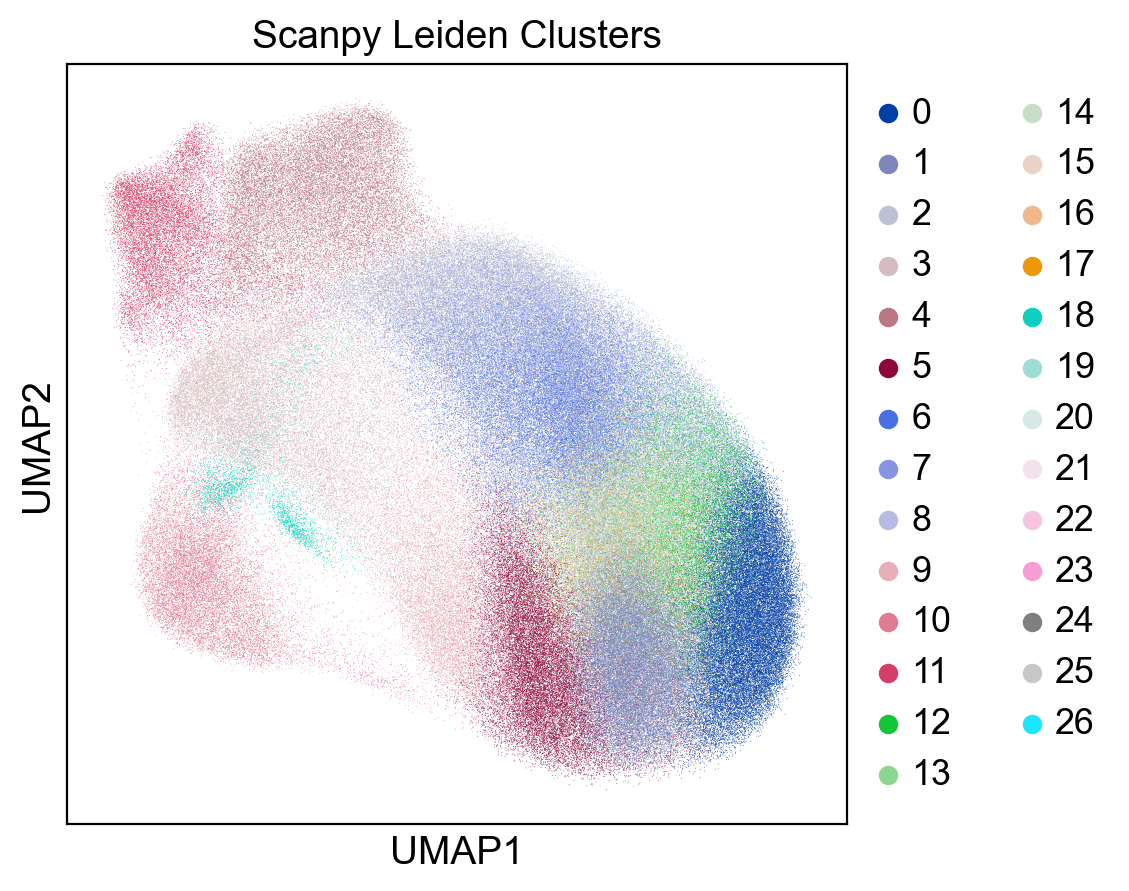

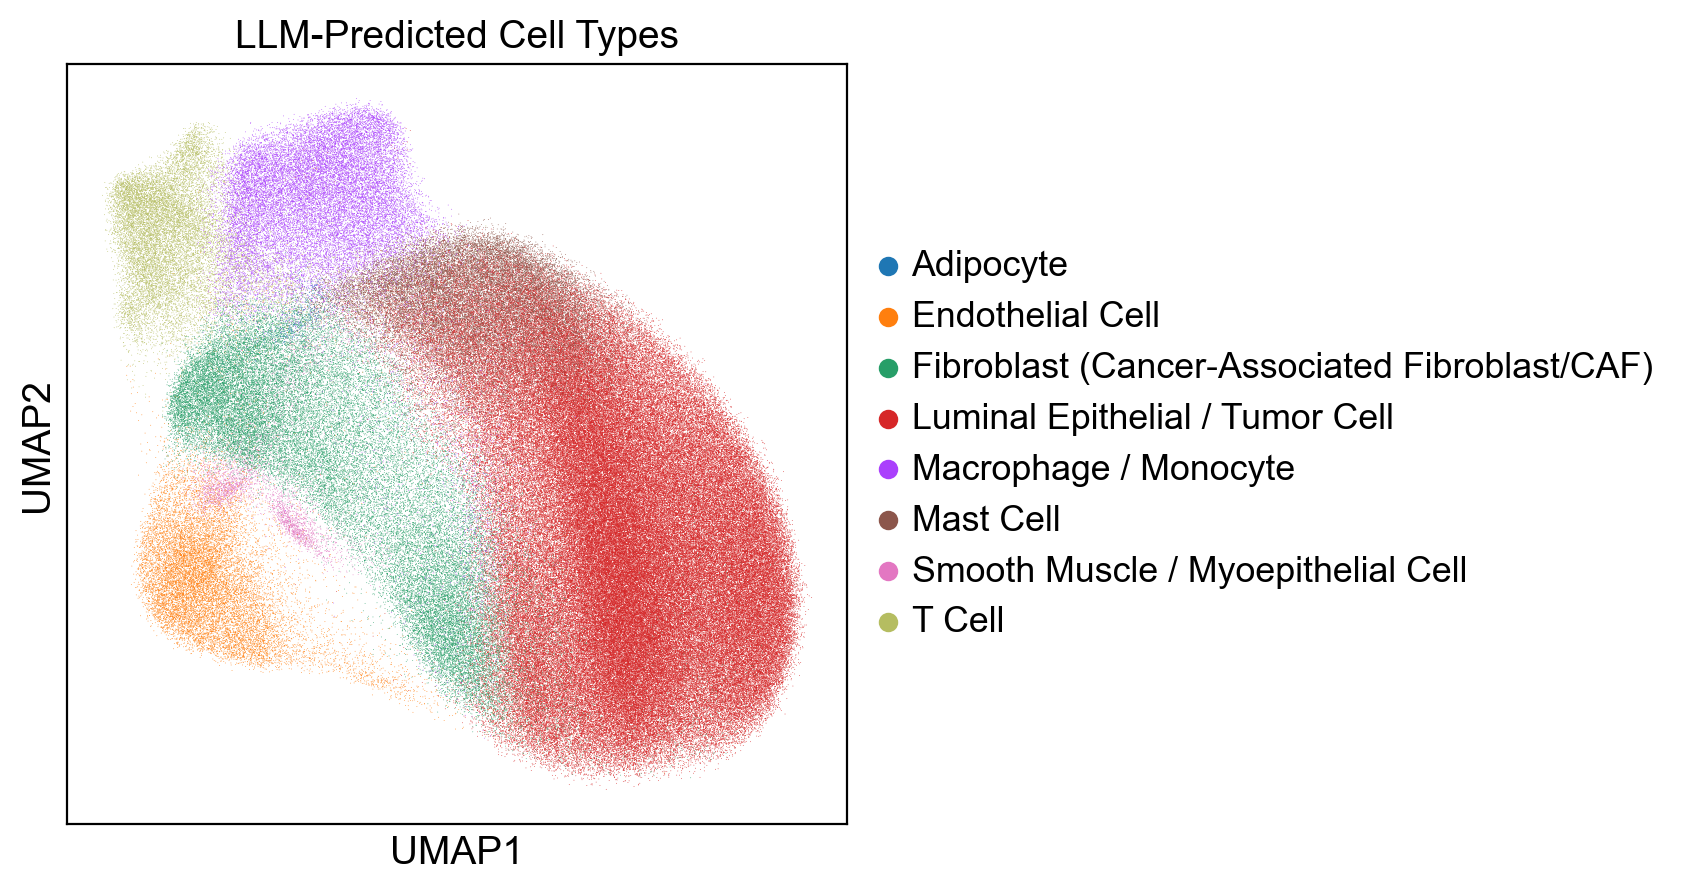

In [7]:
# Cell 4: Visualize Annotation Results
# ------------------------------------

# Plot UMAP colored by original cluster
sc.pl.umap(adata_pred, color=["leiden"], title="Scanpy Leiden Clusters")

# Plot UMAP colored by LLM-predicted cell types
sc.pl.umap(adata_pred, color=["pred_cell_type"], title="LLM-Predicted Cell Types")


In [8]:
import scanpy as sc

# Use Scanpy to rank genes across the groups in 'pred_cell_type'
n_genes = 5
sc.tl.rank_genes_groups(
    adata_pred,
    groupby="pred_cell_type",
    method="t-test",         # or “wilcoxon”, etc.
    n_genes=n_genes,
    key_added="rank_genes_by_pred"  # store results under adata_pred.uns["rank_genes_by_pred"]
)

ranking genes
    finished (0:00:03)


In [9]:
import pandas as pd

# Pull out the Scanpy‐computed result
result = adata_pred.uns["rank_genes_by_pred"]
cell_types = result["names"].dtype.names  # a tuple of all cell‐type names

# Build a DataFrame with one block per cell type
dfs = []
for cell_type in cell_types:
    genes = result["names"][cell_type][:n_genes].tolist()
    scores = result["scores"][cell_type][:n_genes].tolist()
    df_temp = pd.DataFrame({
        "cell_type": cell_type,
        "gene": genes,
        "score": scores
    })
    dfs.append(df_temp)

# Concatenate so that each row is: (cell_type, gene, score)
df_top = pd.concat(dfs, ignore_index=True)
df_top

,cell_type,gene,score
0,Adipocyte,ADH1B,27.113941
1,Adipocyte,ADIPOQ,24.725124
2,Adipocyte,LPL,24.108252
3,Adipocyte,AKR1C1,17.828394
4,Adipocyte,CAV1,13.948677
5,Endothelial Cell,PECAM1,326.977905
6,Endothelial Cell,AQP1,295.991791
7,Endothelial Cell,VWF,252.851669
8,Endothelial Cell,CAV1,240.385574
9,Endothelial Cell,CD93,238.595154


In [10]:
import matplotlib.pyplot as plt
import numpy as np

def plot_top_genes_by_celltype(
    adata,
    key_for_rank="rank_genes_by_pred",
    n_genes=5,
    figsize_per_cell=(4, 2),
    title_suffix=""
):
    """
    Plot the top N genes (+ scores) for each cell type, as horizontal bar charts.
    
    Parameters
    ----------
    adata : AnnData
        Must have `adata.uns[key_for_rank]` present (from sc.tl.rank_genes_groups).
    key_for_rank : str
        Where Scanpy stored rank_genes_groups results (e.g. "rank_genes_by_pred").
    n_genes : int
        How many top genes to plot per cell type.
    figsize_per_cell : tuple
        (width, height) of each subplot. Actual figure size will be
        (width, height * n_cell_types).
    title_suffix : str
        Optional string appended to each subplot’s title.
    """
    # 1) Extract result
    result = adata.uns[key_for_rank]
    cell_types = result["names"].dtype.names  # tuple of cell type names
    n_cells = len(cell_types)
    
    # 2) Create subplots: one row per cell type
    fig, axes = plt.subplots(
        n_cells, 1,
        figsize=(figsize_per_cell[0], figsize_per_cell[1] * n_cells),
        sharex=False
    )
    
    # If only one cell type, axes is not an array
    if n_cells == 1:
        axes = np.array([axes])
    
    # 3) For each cell type, plot horizontal bar
    for i, ct in enumerate(cell_types):
        genes = result["names"][ct][:n_genes]
        scores = result["scores"][ct][:n_genes]
        
        # Reverse order so highest score is on top
        genes = genes[::-1]
        scores = scores[::-1]
        
        ax = axes[i]
        y_positions = np.arange(len(genes))
        
        ax.barh(y_positions, scores, color="steelblue")
        ax.set_yticks(y_positions)
        ax.set_yticklabels(genes, fontsize=10)
        ax.invert_yaxis()  # highest score on top
        ax.set_xlabel("Score", fontsize=10)
        ax.set_title(f"{ct} {title_suffix}", fontsize=12)
        ax.grid(axis="x", linestyle="--", alpha=0.5)
    
    plt.tight_layout()
    plt.show()

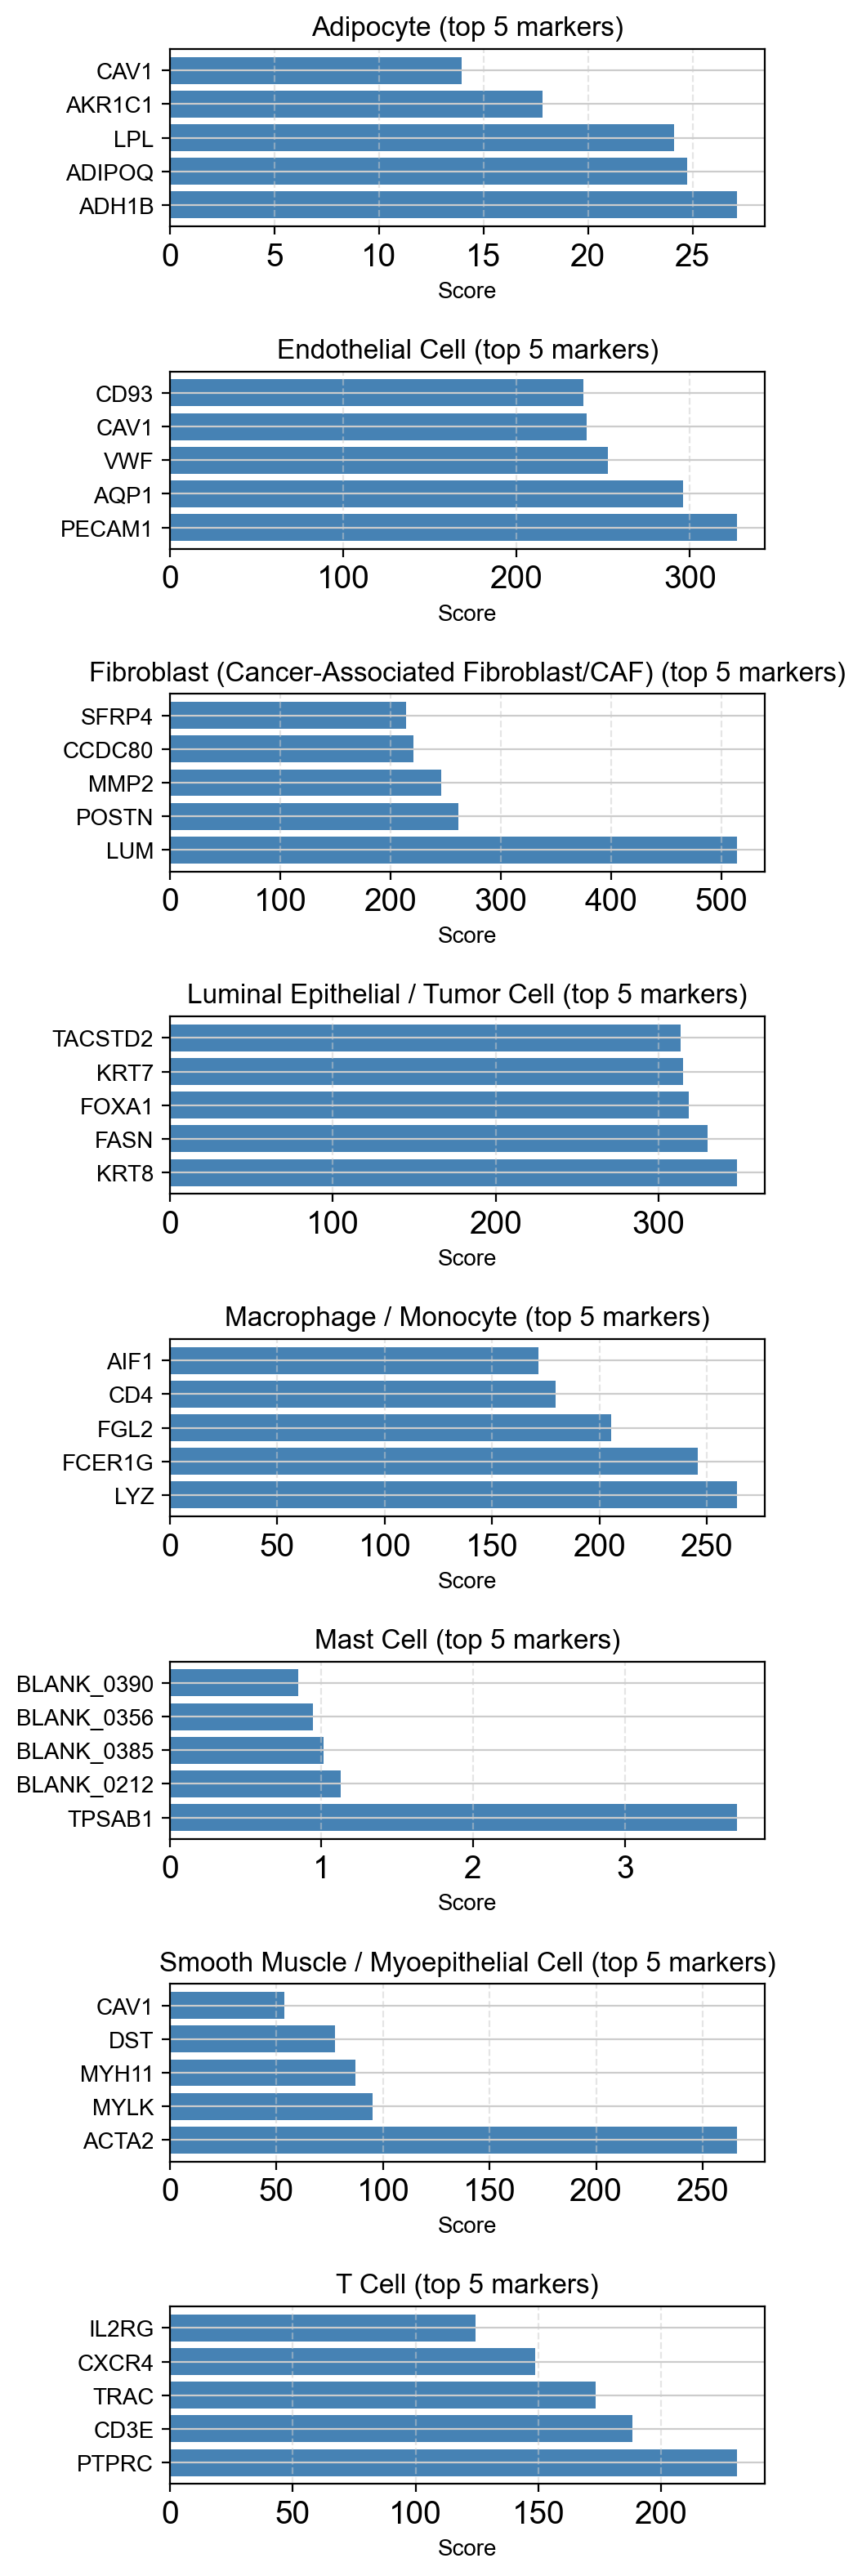

In [11]:
plot_top_genes_by_celltype(
    adata_pred,
    key_for_rank="rank_genes_by_pred",
    n_genes=5,
    figsize_per_cell=(5, 2),
    title_suffix="(top 5 markers)"
)